In [3]:
import pandas as pd

df = pd.read_excel('Food Delivery Time Prediction Case Study.xlsx')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  int64  
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Type_of_order                45593 non-null  object 
 9   Type_of_vehicle              45593 non-null  object 
 10  Time_taken(min)              45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


In [6]:
df.describe()


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_taken(min)
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [11]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'delivery_delay', 'distance'],
      dtype='object')

**Problem Statement:**

A food delivery platform wants to improve service reliability by understanding delivery delays.
This project analyzes delivery time data to identify factors affecting delays and improve performance.

**Key Questions:**

1. What is the average delivery time?
2. Does distance affect delivery time?
3. Does vehicle type impact delivery speed?
4. Do delivery ratings influence performance?

**Website Structure:**

1. Home (Problem)
2. Dataset Overview
3. Analysis (Charts)
4. Insights

In [12]:
df.rename(columns={'Time_taken(min)': 'delivery_delay'}, inplace=True)

In [13]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Type_of_order,0
Type_of_vehicle,0


In [14]:
df = df.drop_duplicates()

In [15]:
import numpy as np

df['distance'] = np.sqrt(
    (df['Restaurant_latitude'] - df['Delivery_location_latitude'])**2 +
    (df['Restaurant_longitude'] - df['Delivery_location_longitude'])**2
)

In [16]:
df.to_csv('cleaned_data.csv', index=False)

**Data Cleaning:**

- No missing values found
- Duplicate rows removed
- Column renamed for clarity
- New feature "distance" created using coordinates

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

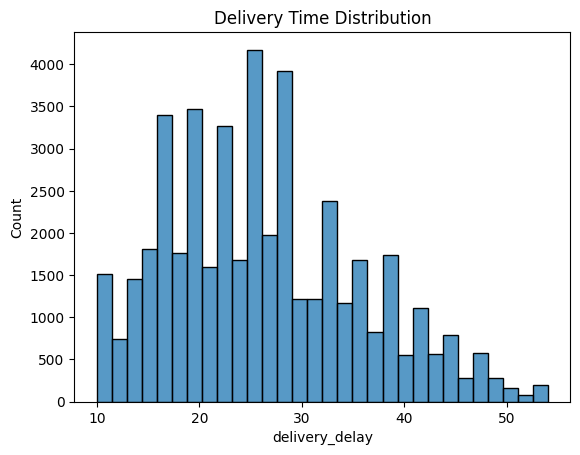

In [18]:
sns.histplot(df['delivery_delay'], bins=30)
plt.title("Delivery Time Distribution")
plt.savefig('dist.png')
plt.show()

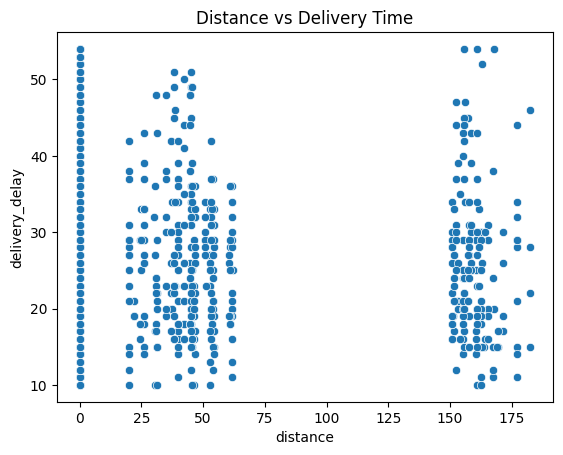

In [19]:
sns.scatterplot(x=df['distance'], y=df['delivery_delay'])
plt.title("Distance vs Delivery Time")
plt.savefig('distance.png')
plt.show()

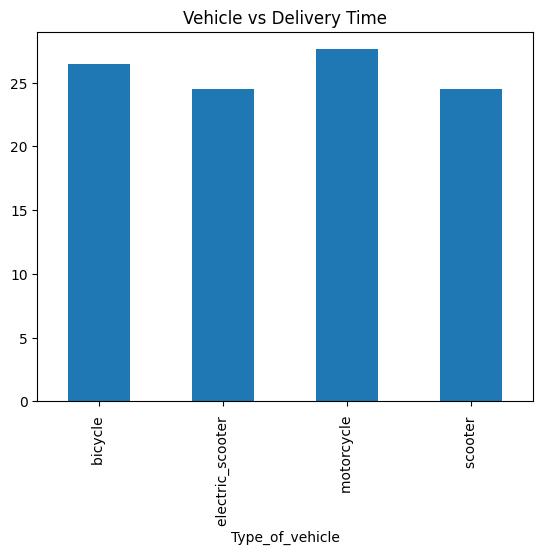

In [20]:
df.groupby('Type_of_vehicle')['delivery_delay'].mean().plot(kind='bar')
plt.title("Vehicle vs Delivery Time")
plt.savefig('vehicle.png')
plt.show()

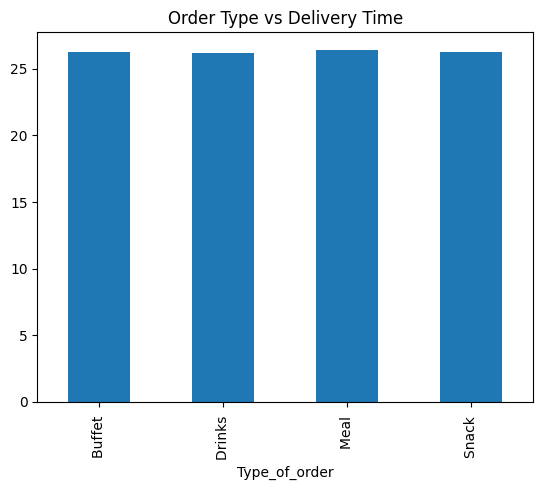

In [21]:
df.groupby('Type_of_order')['delivery_delay'].mean().plot(kind='bar')
plt.title("Order Type vs Delivery Time")
plt.savefig('order.png')
plt.show()

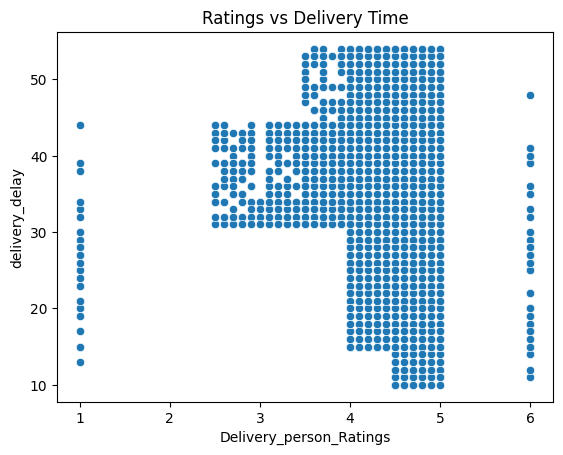

In [22]:
sns.scatterplot(x=df['Delivery_person_Ratings'], y=df['delivery_delay'])
plt.title("Ratings vs Delivery Time")
plt.savefig('ratings.png')
plt.show()

**Insights:**

- Most deliveries are completed within 25–40 minutes
- Delivery time increases with distance
- Vehicle type significantly impacts delivery performance
- Higher-rated delivery personnel deliver faster
- Some extreme delays indicate inefficiencies